In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [3]:
from google.colab import drive
drive.mount('/content/drive')

img=cv2.imread("/content/drive/MyDrive/opencv/chobooo.png")

Mounted at /content/drive


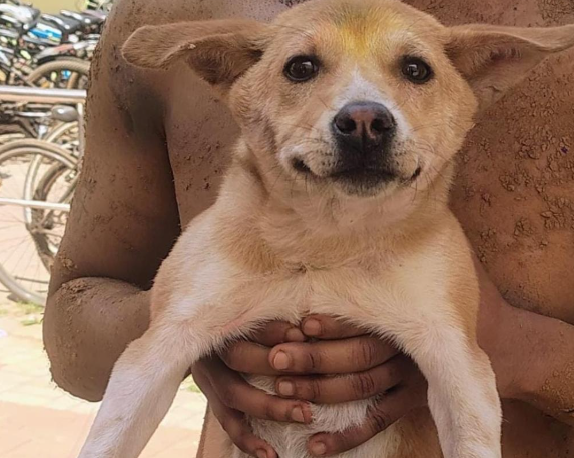

In [4]:
from google.colab.patches import cv2_imshow
cv2_imshow(img)

In [5]:
greyscale_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

Now , we have to check the brightness distribution of this image 

For grayscale, just count occurrences of each intensity value 0–255 across all pixels. That's it — no transformation, just counting.

flat and spread out = well-balanced
bunched to one side = under/overexposed
two humps = bimodal (a clear foreground/background split).

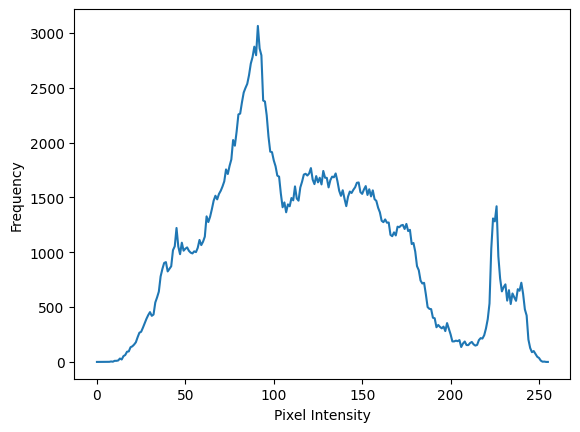

In [6]:
hist = cv2.calcHist([greyscale_img], [0], None, [256], [0, 256])
plt.plot(hist)
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

CLAHE Instead of stretching contrast across the whole image at once, CLAHE breaks the image into small tiles (e.g. an 8×8 grid) and equalizes each tile locally. A "clip limit" caps how aggressively any one tile's contrast can be boosted, so it doesn't amplify noise into garbage.

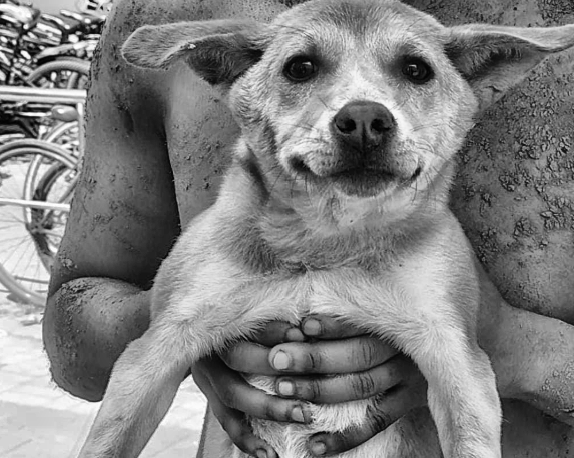

In [7]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
result = clahe.apply(greyscale_img)
cv2_imshow(result)

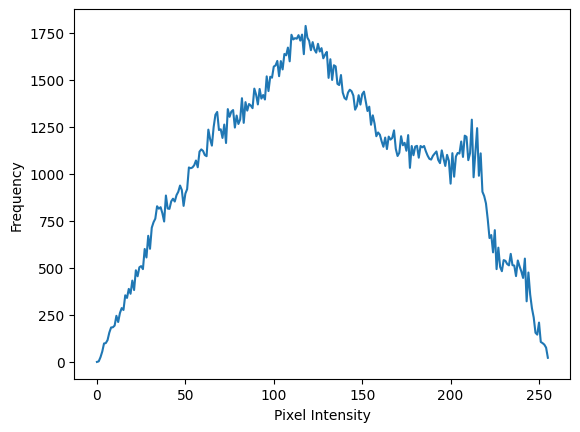

In [8]:
histogram = cv2.calcHist([result], [0], None, [256], [0, 256])
plt.plot(histogram)
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

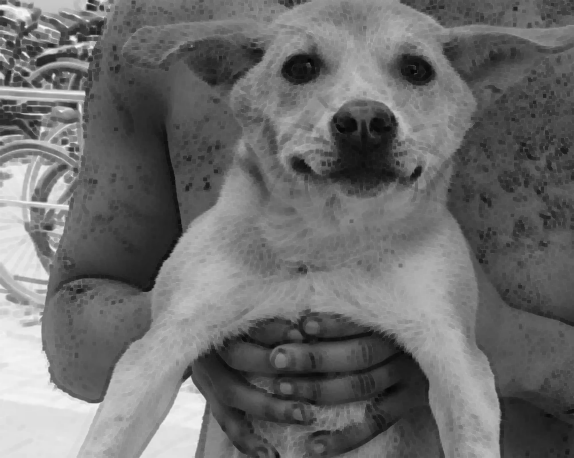

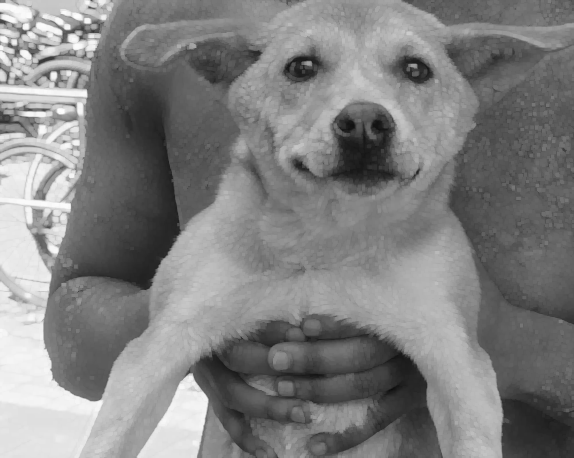

In [9]:
kernel = np.ones((3,3), np.float32)
eroded = cv2.erode(greyscale_img, kernel, iterations=1)
dilated= cv2.dilate(greyscale_img, kernel, iterations=1)
cv2_imshow(eroded)
cv2_imshow(dilated)

OPENING AND CLOSING - 
Opening (Erosion → then Dilation)
Intuition

Erode first (kills small noise specks), then dilate (restores the size of what survived). Net effect: removes noise without shrinking your actual objects.

What problem it solves

"Salt" noise — small white speckles scattered on a mostly-black background — without permanently damaging real object size.

Code
python
opened = cv2.morphologyEx(binary_img, cv2.MORPH_OPEN, kernel)
Common mistakes
Assuming opening = erosion — opening's whole point is that the dilation step afterward undoes the shrinkage, but you still lose anything erosion fully deleted (e.g. an object smaller than the kernel gets erased and never comes back).
Closing (Dilation → then Erosion)
Intuition

Dilate first (fills small holes/gaps), then erode (shrinks back down to near-original size). Net effect: fills small holes/gaps without permanently growing your objects.

What problem it solves

"Pepper" noise — small black holes inside white objects — and reconnecting a slightly broken object outline (common after edge detection or a noisy threshold).

Code
python
closed = cv2.morphologyEx(binary_img, cv2.MORPH_CLOSE, kernel)


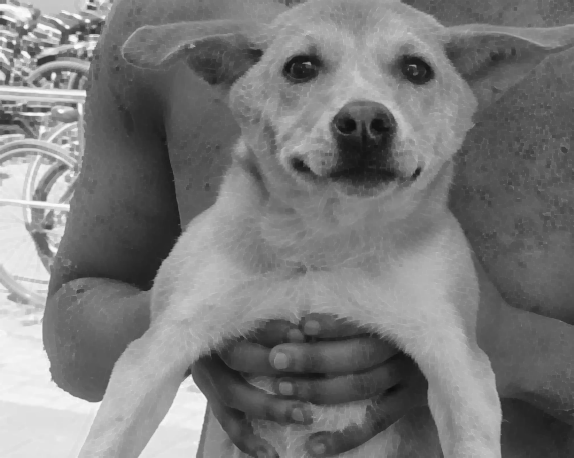

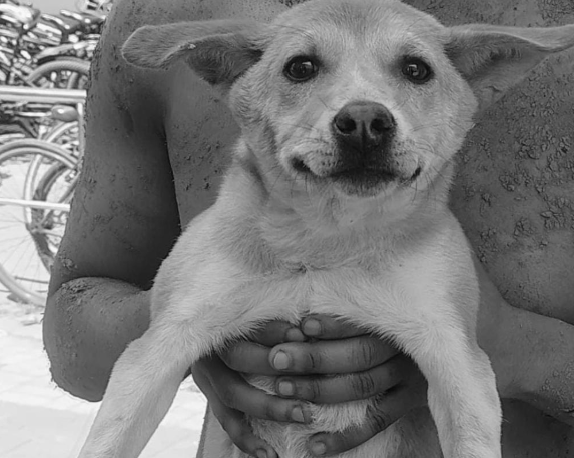

In [10]:
img2 = cv2.morphologyEx(greyscale_img, cv2.MORPH_OPEN, kernel)
img2= cv2.morphologyEx(greyscale_img, cv2.MORPH_CLOSE, kernel)
cv2_imshow(img2)
cv2_imshow(greyscale_img)


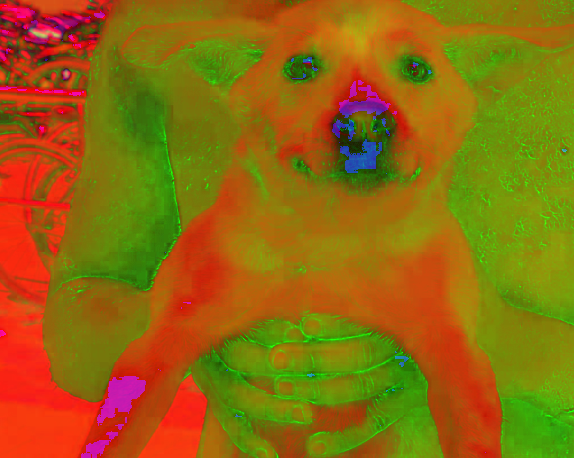

In [12]:
#converting to hsv color space
hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
cv2_imshow(hsv_img)


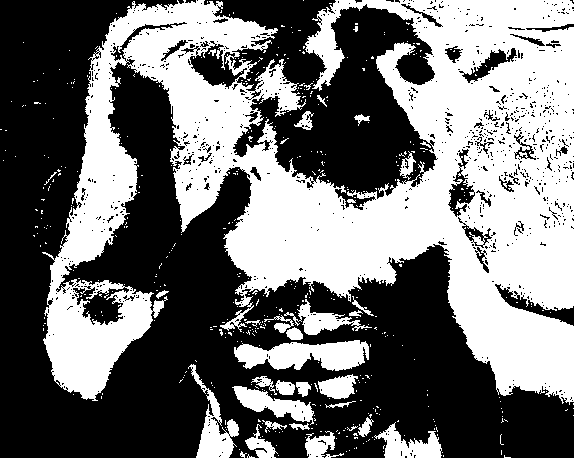

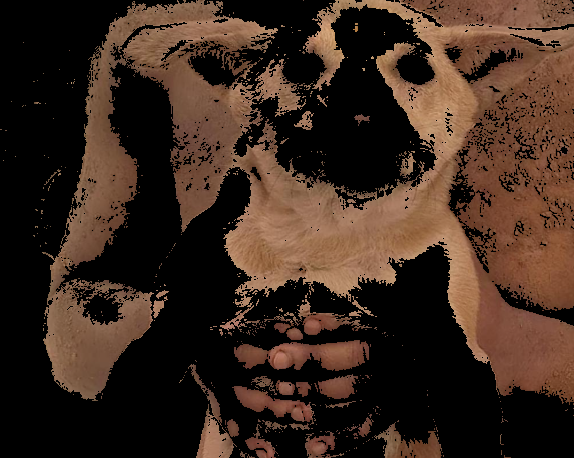

In [14]:
#color thresholding 
lower_orange = np.array([5, 100, 100])
upper_orange = np.array([15, 255, 255])

mask = cv2.inRange(hsv_img, lower_orange, upper_orange)
result = cv2.bitwise_and(img, img, mask=mask)
cv2_imshow(mask)
cv2_imshow(result)

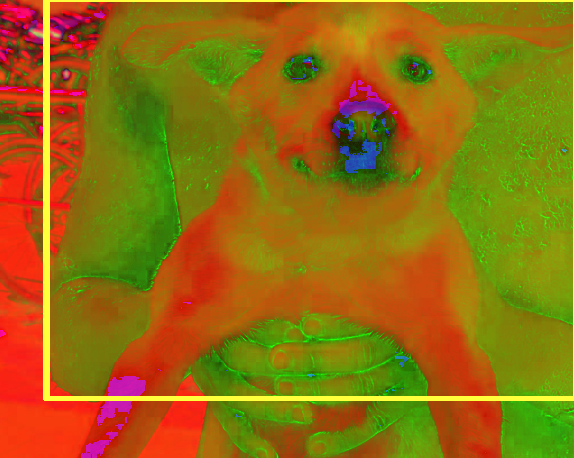

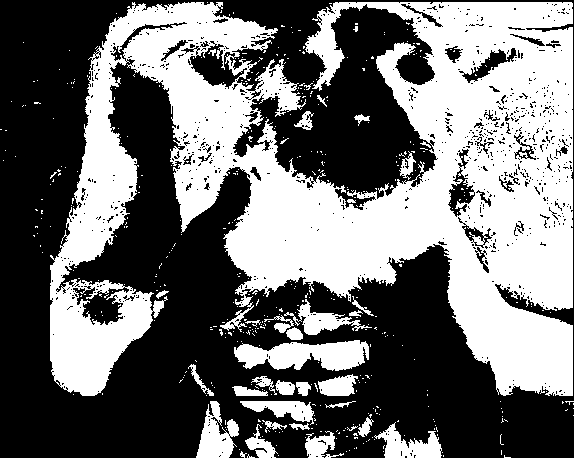

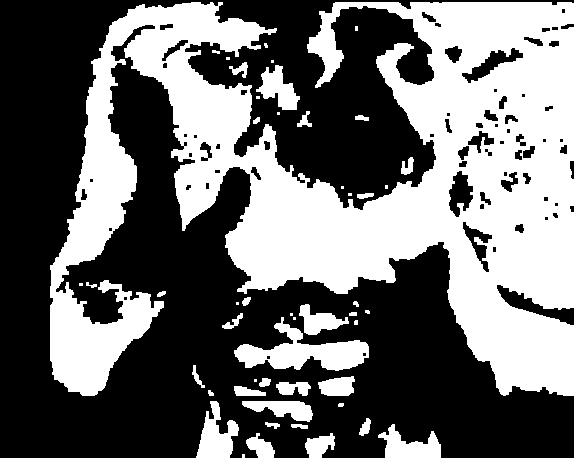

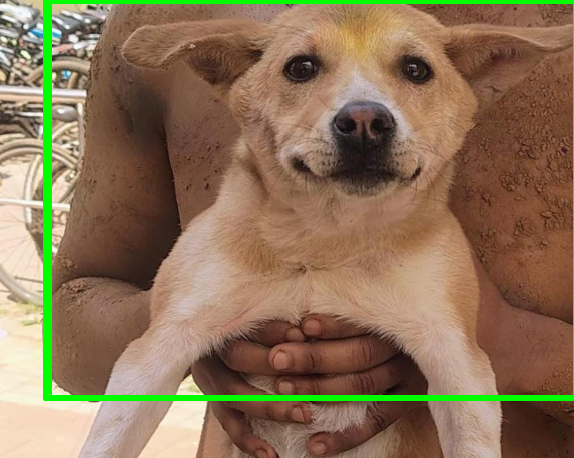

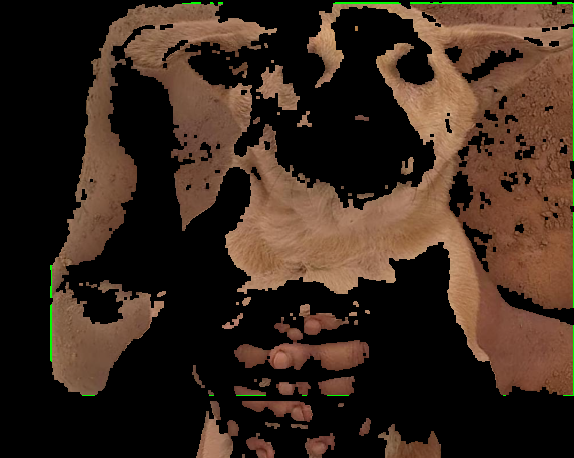

In [ ]:
#the final pipeline 
#we will learn how to do this in the next section, but for now, here is a preview of what the final pipeline will look like:


# 1. Convert to HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
cv2_imshow(hsv)

# 2. Threshold for the target color
lower = np.array([5, 100, 100])
upper = np.array([15, 255, 255])
mask = cv2.inRange(hsv, lower, upper)
cv2_imshow(mask)

# 3. Clean up the mask (morphology from Section 2!)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8))
cv2_imshow(mask)

# 4. Find the object's contour (preview of Section 5)
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if contours:
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
    
cv2_imshow(img)

# 5. (Optional) extract just the object
result = cv2.bitwise_and(img, img, mask=mask)
cv2_imshow(result)